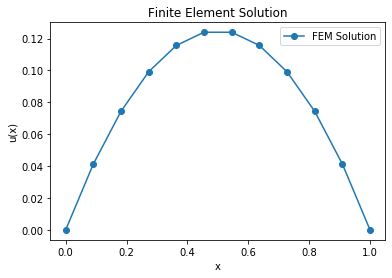

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# Problem setup
L = 1  # Length of the domain
N = 10  # Number of elements
h = L / (N + 1)  # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

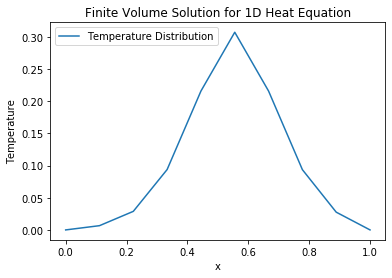

In [5]:
# Parameters
alpha = 0.01  # Diffusion coefficient
dx = 0.1
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx)  # Initial temperature distribution
u[int(Nx/2)] = 1.0  # Initial heat at the center

# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

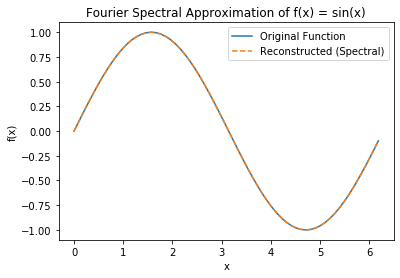

In [10]:
from scipy.fftpack import fft, ifft

# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)

# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real

# Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed (Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()

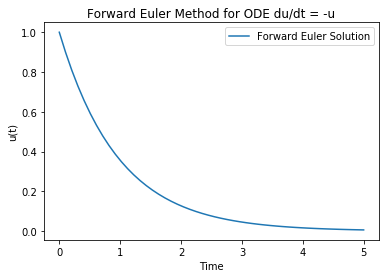

In [11]:
# Define parameters
T = 5.0  # Final time
dt = 0.1  # Time step
N = int(T / dt)
u = np.zeros(N)
u[0] = 1  # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]

#Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()

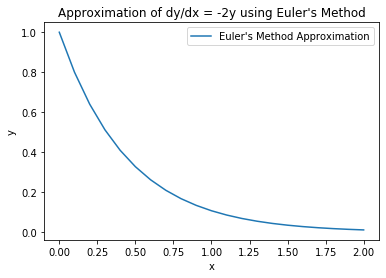

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = 0.1  # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1  # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

# Challenge 15:


h = 0.01
Error: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.0

h = 0.060000000000000005
Error: [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0.01021165 0.00951235 0.00883622 0.00818748 0.00756906 0.00698281
 0.00642971 0.0059101  0.00542373 0.0049

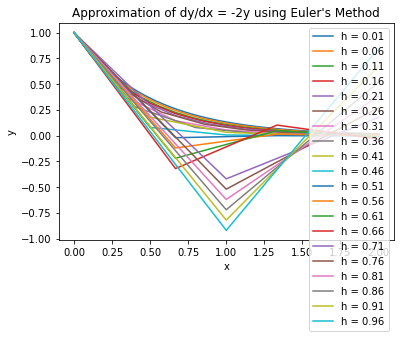

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
x_start, x_end = 0, 2

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

first_x = None
first_y = None

for h in np.arange(0.01, 1.01, 0.05):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  # y(0) = 1
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    if first_x is None:
        first_x = x_values
        first_y = y_values
        
    first_interp = np.interp(x_values, first_x, first_y)
    error = np.abs(y_values - first_interp)
    total_error = np.sum(error)

    print("\nh =", h)
    print("Error:", error)
    print("Total accumulated error:", total_error)
    
    # Plot the results
    plt.plot(x_values, y_values, label=f"h = {h:.2f}")
    
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()